# Surface modes inside the physical CLN

This example keeps the stage-B **source-break terminal port**, perfectly conducting return enclosure and exactly zero conductivity in air. It condenses the magnetostatic air field onto the conductor interface, then restricts the tangential trace to a nested Steklov space. The electric-field recursion remains the energy-normalized physical Type2 CLN; no snapshot/POD or fitted Foster response replaces it.

Independent Claude Opus 5.5 numerical review gave scientific acceptance at `7a3b1606bd2a69e420fdba7b9efad0abb88f0743`, with no P1/P2 findings. This status/wording-only update changes no numerical data, code cells or execution outputs. Publication and remote CI remain separate checks. The examples are matched stage-B meshes; truncation error is measured against the full response on that mesh. It is separate from continuum FE accuracy.

In [1]:
import json, pathlib, numpy as np, matplotlib.pyplot as plt
DATA=pathlib.Path("data")
study=json.loads((DATA/"surface_air.json").read_text())
assert study["complete"]
for cohort in study["cases"]:
 print(cohort["tag"],cohort["mesh"]["ne"],cohort["seconds"],cohort["exact_gauge_schur_control"])

notched_p1_base 695 2.391676902770996 {'original_residual': 2.470917450324171e-14, 'magnetic_field_relative': 5.872260068339022e-15, 'compliance_relative': 2.220446049250313e-15, 'air_load_norm': 0.0, 'mixed_controls': [{'s': [62831.853071795864, 0.0], 'Z': [0.00019577083930673588, 0.0], 'port_relative': 0.0, 'magnetic_field_relative': 5.018697210304906e-15, 'original_residual': 3.836405936364196e-15, 'continuity_residual': 1.1970436170578129e-15}, {'s': [0.0, 6283.185307179586], 'Z': [4.274484474129359e-05, 1.6675683708669547e-05], 'port_relative': 2.7517604971112095e-16, 'magnetic_field_relative': 5.304163276543242e-15, 'original_residual': 1.4270894858352857e-14, 'continuity_residual': 1.351390481424346e-15}, {'s': [0.0, 62831.853071795864], 'Z': [5.864925770983099e-05, 0.00015894801534552475], 'port_relative': 1.0433184886155083e-15, 'magnetic_field_relative': 4.858851574662323e-15, 'original_residual': 3.897619447395878e-15, 'continuity_residual': 1.313076596621262e-15}, {'s': [0.

## Exact air elimination on the gradient quotient

For tangential interface trace g, solve the compatible air harmonic extension E g with zero outer/endplate trace. The physical curl-curl interior operator is singular in gradient directions. Its inverse is taken **only on its positive range**, with compatibility checked, rather than replaced by an epsilon inverse:

$$E=-K_{aa}^{+}K_{a\Gamma},\qquad S_\Gamma=K_{\Gamma\Gamma}^{air}+K_{\Gamma a}^{air}E.$$

S is symmetric and nonnegative. Its trace kernel is retained explicitly. A separate exact Schur elimination of the original production-gauged magnetic block reconstructs the full field and checks the original equations; the gauge penalty is not counted as physical air energy. The full-rank trace model must recover stage-B Z, all eight elements and both energy parts.

The tangential surface mass W is integrated on the actual interface. Positive Steklov vectors are W-orthonormal eigenvectors of S on a declared canonical trace-kernel quotient. K counts these positive modes, separately from trace-kernel and protected port channels.

## Stable truncation and the direction of the energy inequality

The admissible trace space contains all trace-kernel channels, a protected **actual DC port trace**, and the first K positive Steklov vectors. Omitted trace coefficients are **clamped**. They are not turned into zero-cost free coordinates. Conductor interior DOFs remain.

At fixed compatible current load f, the magnetic compliance is

$$\ell_K=f^T Q_K(Q_K^T K Q_K)^{-1}Q_K^T f
=\max_{A\in V_K}(2 f^T A-A^T K A).$$

It increases toward its full-space magnetic compliance from below under nested enrichment. For the one-volt DC load, compliance is G0 squared times L1; only a unit-current load has compliance numerically equal to an inductance. The split conductor/air energies, voltage-driven Z and individual Cauer elements need not be monotone. A rank-K replacement of S on an *unrestricted* trace is a different model; the K=0 negative control exposes a source-coupled zero-cost direction.

The protected DC trace makes DC compliance and L1 exact by construction. This is **not independent evidence that K=0 captures the exterior**. The unprotected DC control and finite-frequency responses are therefore reported too. In the coax, the exterior response is nearly one-dimensional for the stated port; the dynamic small-K test is a useful diagnostic.

In [2]:
for c in study["cases"]:
 print("\n",c["tag"],"unprotected DC controls:",c["unprotected_DC_control"])
 print("K | magnetic dimension | largest fixed-source relative compliance gap | max surface-Z error")
 full=np.array(c["full_fixed_source_compliance"])
 for x in c["cases"]:
  gap=np.max(1-np.array(x["fixed_source_compliance"])/full)
  error=max(v["surface_response_error"] for run in x["runs"] for v in run["frequency"])
  print(x["K"],x["magnetic_dimension"],gap,error)
 print("protected rank / trace-kernel rank:",c["cases"][0]["protected_port_rank"],c["cases"][0]["trace_kernel_rank"])


 notched_p1_base unprotected DC controls: [{'K': 0, 'DC_compliance': 0.2868639313784747, 'relative_gap': 0.8044966081619067}, {'K': 4, 'DC_compliance': 1.3914851319147143, 'relative_gap': 0.05167560914904079}, {'K': 46, 'DC_compliance': 1.4673092301950557, 'relative_gap': -1.1102230246251565e-15}]
K | magnetic dimension | largest fixed-source relative compliance gap | max surface-Z error
0 94 0.426641420851129 0.8064284851763036
1 95 0.3987039069739893 0.7712866977632138
2 96 0.3974572306841335 0.7699521751955055
4 98 0.343739180494666 0.5661338915171801
8 102 0.3375230517666563 0.5290381300874749
16 110 0.28948467254879096 0.42975805594024874
32 126 0.02817934060863203 0.030086251837058757
46 139 1.7763568394002505e-15 1.2725077513357556e-13
protected rank / trace-kernel rank: 1 68

 coax_p1_base unprotected DC controls: [{'K': 0, 'DC_compliance': 0.01989586008843014, 'relative_gap': 0.8178673484977627}, {'K': 4, 'DC_compliance': 0.10921711911869361, 'relative_gap': 0.000193839014228

In [3]:
# Analytic exterior energy is separate from the matched-mesh control.
coax=next(c for c in study["cases"] if c["tag"]=="coax_p1_base")
mu=4e-7*np.pi; exact_air=mu*.015*np.log(3)/(2*np.pi)
reference=json.loads((DATA/"general_3d_air.json").read_text())
full=next(c for c in reference["cases"] if c["tag"]=="coax_p1_base")
print("Exact coax L_air [nH]:",exact_air*1e9)
for x in [coax["cases"][0],coax["cases"][-1]]:
 print("K",x["K"],"DC conductor/air inductance [nH]:",np.array(x["runs"][0]["energy_parts"][0])*1e9)
 print("air relative oracle error:",abs(x["runs"][0]["energy_parts"][0][1]/exact_air-1))
 print("full Z oracle errors at sampled Hz:",[(row["hz"],abs(complex(*row["Z"])/complex(*old["oracle_Z"])-1)) for row,old in zip(x["runs"][0]["frequency"],full["runs"][0]["frequency"])])

Exact coax L_air [nH]: 3.295836866004329
K 0 DC conductor/air inductance [nH]: [0.72617264 3.25874988]
air relative oracle error: 0.011252675397055434
full Z oracle errors at sampled Hz: [(1000.0, 0.001986264497807494), (10000.0, 0.011771592612189056), (100000.0, 0.018506181779377122), (1000000.0, 0.03537302761872739)]
K 386 DC conductor/air inductance [nH]: [0.72617264 3.25874988]
air relative oracle error: 0.011252675397052436
full Z oracle errors at sampled Hz: [(1000.0, 0.001986267822725939), (10000.0, 0.011773519745514285), (100000.0, 0.018449102564205712), (1000000.0, 0.03510332725689931)]


## Physical eight-element ladders at zero and positive real expansion points

The magnetic inverse uses total conductor-plus-condensed-air energy. Inductive loads are restricted to the conductor. For q=s-s0 the final qL branch terminates the Type2 continued fraction. Both s0=0 and real s0=2*pi*10 kHz use four electric modes/eight elements. Saved field arrays are independent copies.

Every K checks positivity, both orthogonalities, ladder/Galerkin equality, power and contact coefficients q0..q7 against its own full constrained-current model. This is distinct from matching the original untruncated stage-B model. q8 is retained as the first unmatched coefficient. Deep elements can converge slowly or non-monotonically even when Z is accurate.

In [4]:
for c in study["cases"]:
 print("\n",c["tag"])
 for x in c["cases"]:
  for run in x["runs"]:
   print("K",x["K"],"s0",run["s0"],"Rhat",run["Rhat"],"inductances",run["L"])
   print("element gaps:",run["element_relative_to_full"],"orth:",run["electric_orth"],run["magnetic_orth"],"contact:",max(run["contact_per_coefficient"]))


 notched_p1_base
K 0 s0 0.0 Rhat [4.254251130042231e-05, 0.0013723634539900922, 0.004258518715301903, 0.0014529892602904758] inductances [2.655632012773966e-09, 6.09511879491336e-09, 5.312328800395578e-09, 3.942669229208402e-09]
element gaps: {'Rhat': [2.220446049250313e-16, 1.2434497875801753e-14, 0.661029163128835, 0.8845805947733687], 'L': [2.220446049250313e-16, 0.2654414802502887, 0.8581723534085257, 0.9710632333594752]} orth: 6.80084713486275e-12 3.17183457820895e-11 contact: 2.2310142364308917e-14
K 0 s0 62831.853071795864 Rhat [0.00019468822666473707, 0.002430039455491751, 0.004182519931843997, 0.0013157386486687729] inductances [2.248436186787938e-09, 6.47724133416014e-09, 2.5306873159021395e-09, 1.0662489843565515e-09]
element gaps: {'Rhat': [0.0055299994924286056, 0.2530147860189822, 0.817724451525393, 0.9867886569551226], 'L': [0.018738363290734306, 0.5118941458075041, 0.9439344330792415, 0.9961757653749541]} orth: 2.8534986884103835e-13 9.85577799914121e-13 contact: 9.865

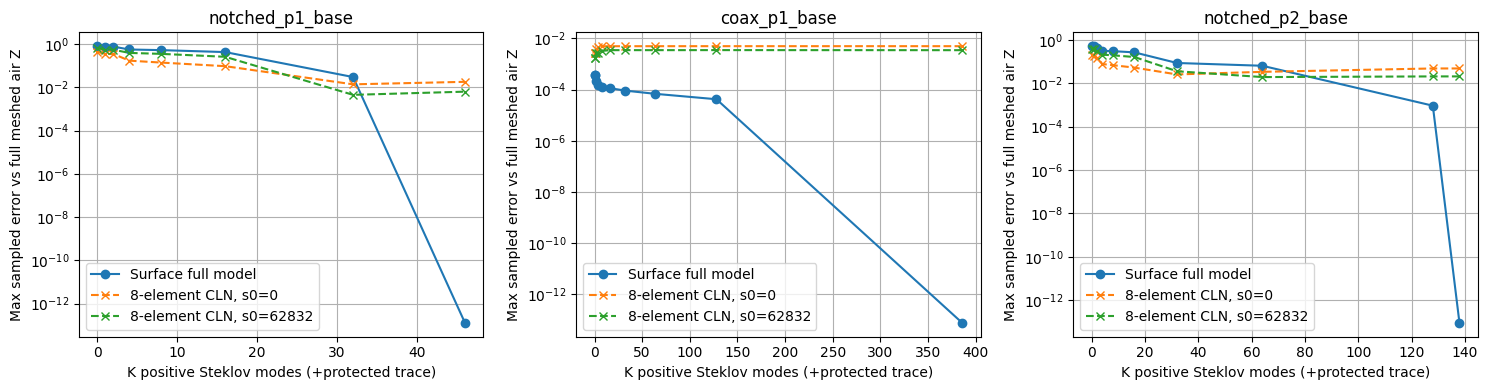

In [5]:
fig,axes=plt.subplots(1,len(study["cases"]),figsize=(15,4),squeeze=False)
for ax,c in zip(axes[0],study["cases"]):
 counts=[x["K"] for x in c["cases"]]
 surface_error=[max(v["surface_response_error"] for v in x["runs"][0]["frequency"]) for x in c["cases"]]
 ax.semilogy(counts,surface_error,"o-",label="Surface full model")
 for shift in [0,1]:
  errors=[max(abs(complex(*row["ladder"])/complex(*row["same_mesh_full_Z"])-1) for row in x["runs"][shift]["frequency"]) for x in c["cases"]]
  ax.semilogy(counts,errors,"x--",label="8-element CLN, s0="+str(round(c["cases"][0]["runs"][shift]["s0"])))
 ax.set_title(c["tag"]);ax.set_xlabel("K positive Steklov modes (+protected trace)");ax.set_ylabel("Max sampled error vs full meshed air Z");ax.grid(True);ax.legend()
plt.tight_layout();plt.show()

## Regional energy, FE scope and reproduction

Energy parts below are voltage-driven conductor/air forms, not fixed-current monotonic quantities. Compare all four sampled frequencies separately. Full-rank agreement is an exact discrete control, not a new continuum accuracy claim. Coarse linear coax fields retain their published FE error; its small surface error does not improve that. The matched quadratic notched case is not an analytic oracle. Corner effects and deep-element errors remain visible.

The present dense quotient/eigensystem implementation targets small and moderate verification meshes; it does not claim scalability to large 3D production models. Region masks, original matrices, harmonic extensions, S/W, eigenvectors and nested bases are exported for the small notched mesh. Larger meshes retain source/mesh identities and numerical results. No nonlinear FP-CLN or T–Omega is added by this notebook.

```text
python validation/cln3d/surface_air_study.py --output docs/data/surface_air.json --export docs/data/surface_air_matrices.json
python validation/validate_surface_air.py
```

Native reproduction needs NGSolve/Netgen, numpy, scipy; reading needs numpy/matplotlib. CI recomputes the original small matrices using numpy/stdlib and checks stored larger-mesh evidence. It does not rerun native FEM. See [NGSolve Schur and harmonic-extension identities](https://ngsolve.org/ngsolve/docs/i-tutorials/unit-1.4-staticcond/staticcond.html). Domain-wide physical quotient condensation is an additional operation implemented here, not the tutorial's element-local condensation flag.

In [6]:
for c in study["cases"]:
 print("\n",c["tag"])
 for x in [c["cases"][0],c["cases"][-1]]:
  for run in x["runs"]:
   print("K",x["K"],"s0",run["s0"],"cumulative L parts",run["energy_parts"])
   print([(row["hz"],row["energy_relative_to_full"]) for row in run["frequency"]])


 notched_p1_base
K 0 s0 0.0 cumulative L parts [[6.480813479717936e-10, 2.0075506648021724e-09], [5.242275390447986e-09, 8.528434044653744e-10], [5.219968841900847e-09, 9.2359958494731e-11], [3.9062773821814024e-09, 3.639184702699949e-11]]
[(1000.0, [0.0007667554598698167, 0.00013721240429886983]), (10000.0, [0.049664467458276684, 0.02677258777338498]), (100000.0, [1.2732153308175636, 0.09569099837383199]), (1000000.0, [53.761853721297555, 0.12314826600264328])]
K 0 s0 62831.853071795864 cumulative L parts [[3.743761641823121e-10, 1.874060022605626e-09], [5.999760190283355e-09, 4.774811438767841e-10], [2.4955482313563056e-09, 3.513908454583377e-11], [1.0613970152256992e-09, 4.851969130852231e-12]]
[(1000.0, [0.0007667554598698167, 0.00013721240429886983]), (10000.0, [0.049664467458276684, 0.02677258777338498]), (100000.0, [1.2732153308175636, 0.09569099837383199]), (1000000.0, [53.761853721297555, 0.12314826600264328])]
K 46 s0 0.0 cumulative L parts [[6.48081347971796e-10, 2.00755066